0.0

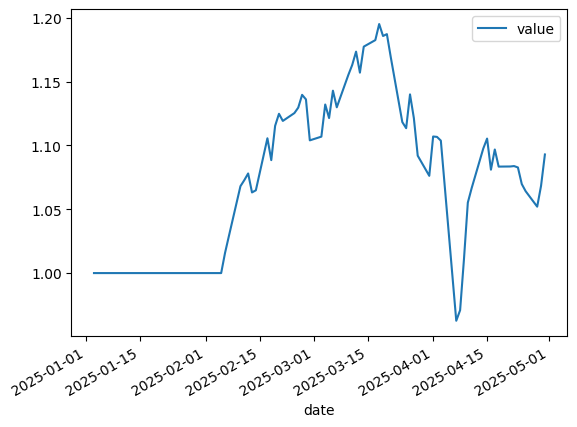

In [2]:
import pandas as pd
import pf_trader

prices = pd.read_csv("prices.csv", parse_dates=["date"])
prices = prices[["date", "instrument", "price"]]
factors = pd.read_csv("factors.csv", parse_dates=["date"])
factors = factors[["date", "instrument", "factor"]]


def main(ctx: pf_trader.Context) -> pd.DataFrame:
    if not ctx.is_rebalance_date:
        return None
    df = factors[factors["date"] == ctx.date]
    df = df.sort_values("factor", ascending=True).head(50)
    df["weight"] = 1.0 / 50
    return df[["instrument", "weight"]]


res = pf_trader.run(
    strategy=main,
    rebalance_period="m",
    buy_cost=0.0,
    sell_cost=0.0,
    slip_cost=0.0,
    prices=prices,
)

res.values.plot(x="date", y="value")
res.trades['cost'].sum()